# GOUB Theta Schedule Visualization

Supports two modes:
- **Mode A**: Single experiment diagnostics (loss + PSNR/SSIM/LPIPS curves)
- **Mode B**: Cross-experiment comparison (compare cosine vs linear vs constant)

In [1]:
import json
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_ROOT = "outputs"

def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def load_experiment(exp_name):
    exp_dir = os.path.join(OUTPUT_ROOT, exp_name)
    train_path = os.path.join(exp_dir, 'log', 'train_metrics.jsonl')
    val_path = os.path.join(exp_dir, 'log', 'val_metrics.jsonl')
    config_path = os.path.join(exp_dir, 'log', 'config.json')
    
    train_data = load_jsonl(train_path) if os.path.exists(train_path) else []
    val_data = load_jsonl(val_path) if os.path.exists(val_path) else []
    config = json.load(open(config_path)) if os.path.exists(config_path) else {}
    
    return {'train': train_data, 'val': val_data, 'config': config}

# Check what's available
exps = sorted({
    os.path.basename(p.rstrip('/')) for p in glob.glob(os.path.join(OUTPUT_ROOT, '*/'))
    if os.path.exists(os.path.join(p, 'log', 'train_metrics.jsonl'))
})
print(f"Found experiments: {exps}")
for e in exps:
    d = load_experiment(e)
    print(f"  {e}: {len(d['train'])} train records, {len(d['val'])} val records")

Found experiments: ['derain_constant', 'derain_cosine', 'derain_linear']
  derain_constant: 2000 train records, 15 val records
  derain_cosine: 2000 train records, 15 val records
  derain_linear: 2133 train records, 16 val records


In [2]:
def visualize_single(exp_name: str, save: bool = True):
    """Mode A: Single experiment diagnostics."""
    data = load_experiment(exp_name)
    if not data['train']:
        print(f"No data found for {exp_name}")
        return
    
    config = data['config']
    schedule = config.get('sde', {}).get('schedule', 'unknown')
    
    train_iters = [r['iter'] for r in data['train']]
    train_loss = [r['loss'] for r in data['train']]
    
    val_iters = [r['iter'] for r in data['val']]
    val_psnr = [r['psnr'] for r in data['val']]
    val_ssim = [r.get('ssim', 0) for r in data['val']]
    val_lpips = [r.get('lpips', 0) for r in data['val']]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{exp_name} ({schedule} schedule)', fontsize=14, fontweight='bold')
    
    # Loss
    ax = axes[0, 0]
    ax.plot(train_iters, train_loss, linewidth=0.5, alpha=0.7, color='blue')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss')
    ax.axhline(y=np.mean(train_loss[-100:]), color='red', linestyle='--', linewidth=0.5, label=f'Final mean: {np.mean(train_loss[-100:]):.4f}')
    ax.legend()
    
    # PSNR
    ax = axes[0, 1]
    ax.plot(val_iters, val_psnr, marker='o', color='green')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('PSNR (dB)')
    ax.set_title('Validation PSNR')
    ax.axhline(y=max(val_psnr), color='red', linestyle='--', linewidth=0.5, label=f'Best: {max(val_psnr):.2f}')
    ax.legend()
    
    # SSIM
    ax = axes[1, 0]
    ax.plot(val_iters, val_ssim, marker='o', color='orange')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('SSIM')
    ax.set_title('Validation SSIM')
    
    # LPIPS
    ax = axes[1, 1]
    ax.plot(val_iters, val_lpips, marker='o', color='purple')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('LPIPS')
    ax.set_title('Validation LPIPS (lower is better)')
    
    plt.tight_layout()
    
    if save:
        save_dir = os.path.join(OUTPUT_ROOT, exp_name, 'plt_fig')
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, 'metrics.png'), dpi=150, bbox_inches='tight')
    
    plt.show()
    return fig

print('visualize_single() ready')

visualize_single() ready


In [3]:
def smooth(y, window=50):
    """Rolling mean smoothing."""
    if len(y) < window:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='valid')

def compare_experiments(exp_names: list, metric: str = 'psnr', save: bool = True, loss_smooth: int = 100):
    """Mode B: Cross-experiment comparison. 2x2 layout: Loss (log), PSNR, SSIM, LPIPS."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    markers = ['o', 's', '^']
    
    for i, exp_name in enumerate(exp_names):
        data = load_experiment(exp_name)
        schedule = data['config'].get('sde', {}).get('schedule', exp_name)
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        
        # Train loss (smoothed + log scale)
        if data['train']:
            train_iters = [r['iter'] for r in data['train']]
            train_loss = [r['loss'] for r in data['train']]
            # faint raw line
            axes[0, 0].plot(train_iters, train_loss, linewidth=0.1, alpha=0.15, color=color)
            # smoothed bold line
            if loss_smooth > 1 and len(train_loss) > loss_smooth:
                smoothed = smooth(train_loss, loss_smooth)
                smooth_iters = train_iters[loss_smooth - 1:]
                axes[0, 0].plot(smooth_iters, smoothed, linewidth=1, color=color, label=schedule)
            else:
                axes[0, 0].plot(train_iters, train_loss, linewidth=0.5, alpha=0.8, color=color, label=schedule)
        
        # Val metrics
        if data['val']:
            val_iters = [r['iter'] for r in data['val']]
            val_psnr = [r['psnr'] for r in data['val']]
            val_ssim = [r.get('ssim', 0) for r in data['val']]
            val_lpips = [r.get('lpips', 0) for r in data['val']]
            
            axes[0, 1].plot(val_iters, val_psnr, marker=marker, color=color, label=f'{schedule} (best: {max(val_psnr):.2f})')
            axes[1, 0].plot(val_iters, val_ssim, marker=marker, color=color, label=f'{schedule} (best: {max(val_ssim):.3f})')
            axes[1, 1].plot(val_iters, val_lpips, marker=marker, color=color, label=f'{schedule} (best: {min(val_lpips):.4f})')
    
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Loss (log)')
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_title(f'Training Loss (log scale)')
    axes[0, 0].legend()
    
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('PSNR (dB)')
    axes[0, 1].set_title('Validation PSNR')
    axes[0, 1].legend()
    
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('SSIM')
    axes[1, 0].set_title('Validation SSIM')
    axes[1, 0].legend()
    
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('LPIPS')
    axes[1, 1].set_title('Validation LPIPS')
    axes[1, 1].legend()
    
    plt.tight_layout()
    
    if save:
        save_dir = os.path.join(OUTPUT_ROOT, 'comparison')
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f'comparison_{metric}.png'), dpi=150, bbox_inches='tight')
    
    plt.show()
    return fig

print('compare_experiments() ready')

compare_experiments() ready



--- Cross-experiment comparison ---


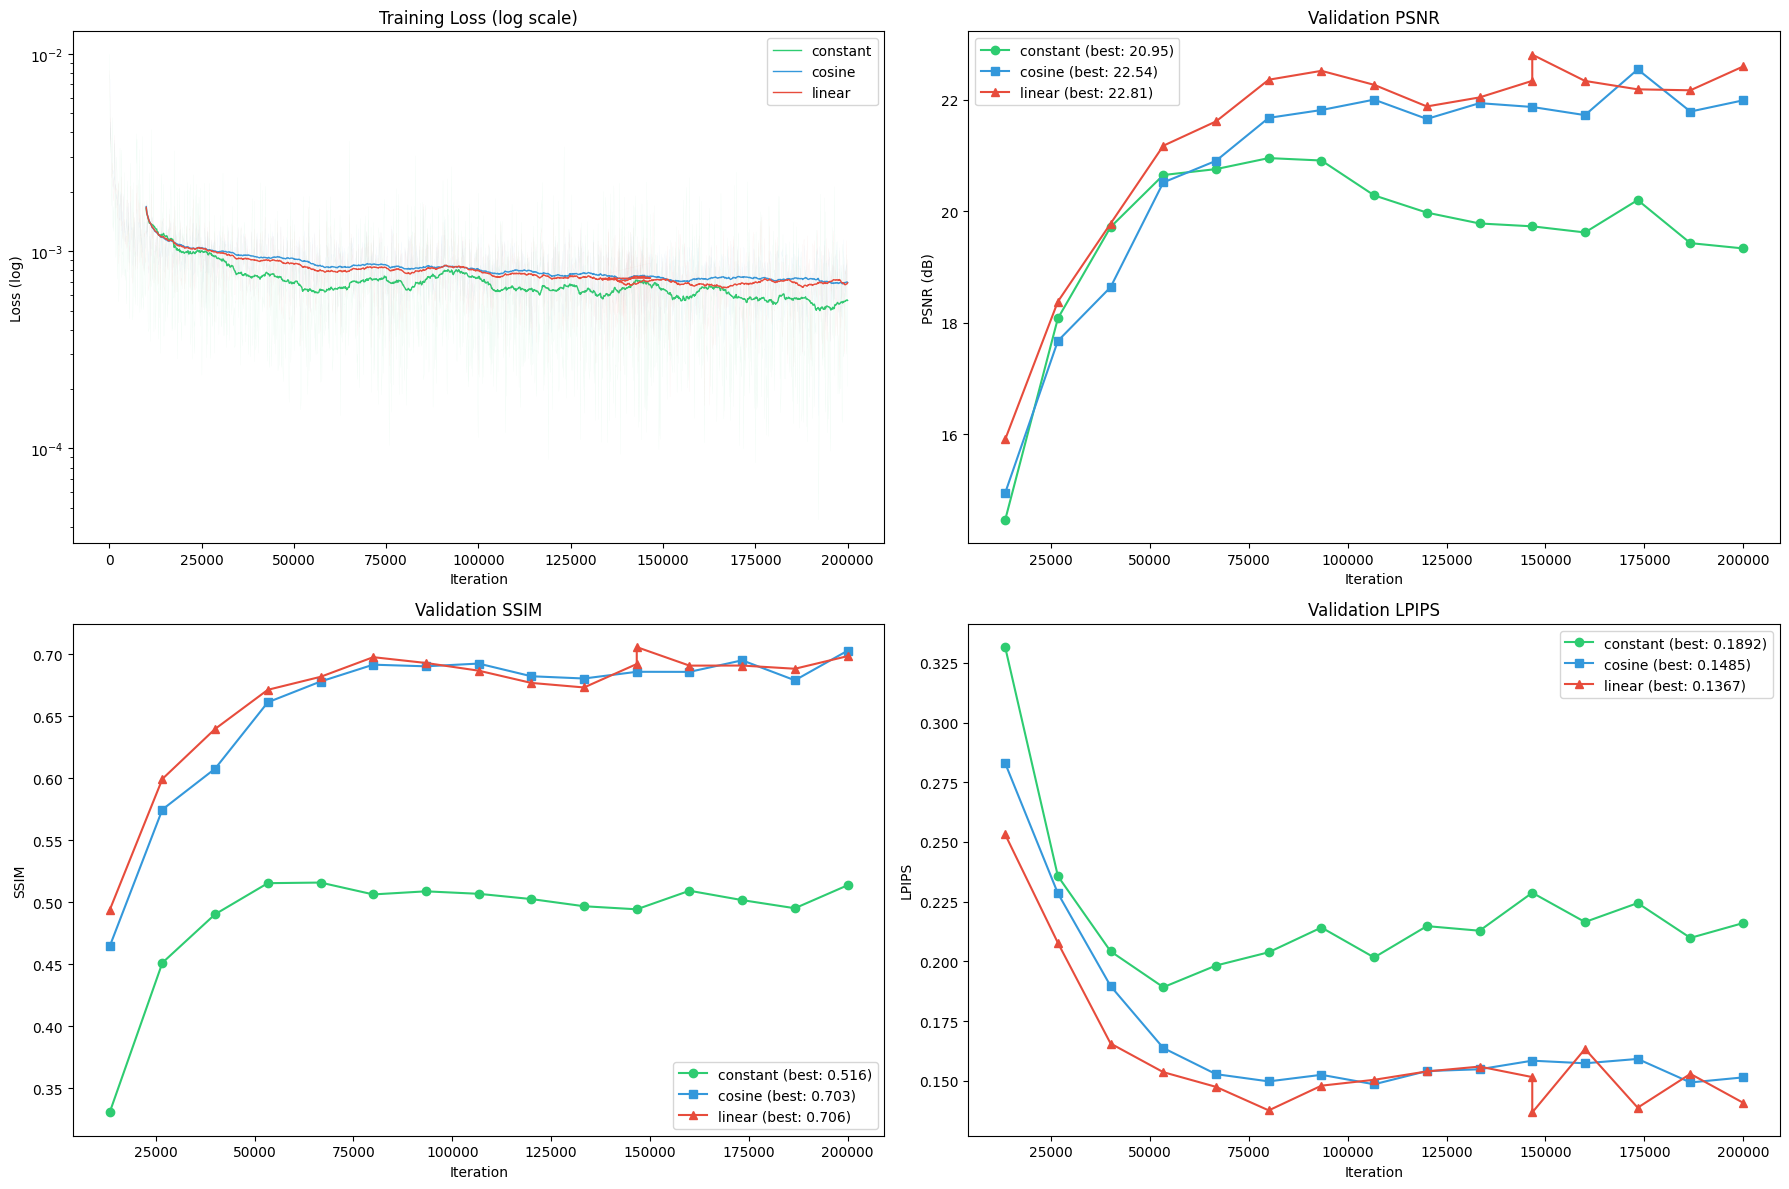

In [4]:
# Auto-detect and call
if len(exps) >= 2:
    print("\n--- Cross-experiment comparison ---")
    compare_experiments(exps)
elif len(exps) == 1:
    print("\n--- Single experiment diagnostics ---")
    visualize_single(exps[0])